In [21]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import folium

In [22]:
# Mac 한글 폰트 설정
plt.rc('font', family='AppleGothic')
plt.rc('axes', unicode_minus=False)

# 데이터 프레임 조회 시 컬럼 줄임 없애기
pd.set_option('display.max_columns', None)

* 참조 - 빅쿼리 직접 호출 관련

In [23]:
# 빅 쿼리 직접 연결용 - 요금이 무섭기 때문에 csv로 진행 ^_^

# from google.cloud import bigquery

# client = bigquery.Client(project="hangang-park")

# # dbt로 생성된 최종 마트 테이블 조회
# sql = """
#     SELECT * 
#     FROM `hangang-park.hangang_park.mart_joined_table`
# """

# # 판다스 데이터프레임으로 변환
# df = client.query(sql).to_dataframe()

# 🅿️ 한강공원 주차장 EDA

* 분석 대상 범위: <br>
전체 한강공원 주차장은 총 30개소이나, 일별 이용 현황 데이터는 28개소만 집계되고 있습니다.

* 마스터 데이터 활용: <br>
일별 시계열 분석 시 2개 주차장이 제외되므로, 주차장 기본 제원 및 전반적인 특성 파악은 누락이 없는 `park_master 테이블(30개소 전체)`을 기준으로 먼저 진행합니다.

## 데이터 호출

In [ ]:
master_df = pd.read_csv('../data/pre_processed/park_master.csv')

In [ ]:
# 지구 코드 고유 수 파악
master_df['DSTRCT_TYPE'].nunique() # 11
# 지구 코드 고유 내용 파악
master_df['DSTRCT_TYPE'].unique() # ['강서', '광나루', '난지', '뚝섬', '망원', '반포', '양화', '여의도', '이촌', '잠실', '잠원']

# 주차장 고유 수 파악
master_df['PKLT_TYPE'].nunique() # 30

# 면수
master_df['PRK_CNT'].min() # 20
master_df['PRK_CNT'].max() # 785
# 장애면수
master_df['PWDBS_PRK_CNT'].unique() # [0]
# 정기면수
master_df['PRD_PRK_CNT'].unique() # [0]

# 주중 이용시간 시작
master_df['WD_OPER_BGNG_TM'].unique() # [06:00]
# 주중 이용시간 종료
master_df['WD_OPER_END_TM'].unique() # [23:00]
# 주말 이용시간 시작
master_df['WE_OPER_BGNG_TM'].unique() # [06:00]
# 주중 이용시간 종료
master_df['WE_OPER_END_TM'].unique() # [23:00]

# 면제 시간
master_df['EXMPTN_HR'].unique() # [10, 0]
# 기본 시간
master_df['BSC_HR'].unique() # [30]
# 기본 요금
master_df['BSC_CRG'].unique() # [1000, 2000]
# 간격 시간
master_df['INTR_HR'].unique() # [10]
# 간격 요금
master_df['INTR_CRG'].unique() # [200, 300]
# 전일 요금
master_df['PRVDY_CRG'].unique() # [10000, 15000, 0]
# 주간 요금
master_df['WKLY_CRG'].unique() # [0]
# 야간 요금
master_df['NGHT_CRG'].unique() # [0]
# 정기권 금액
master_df['PRD_AMT'].unique() # [50000, 1000000]
# 주차장 운영업체
master_df['PKLT_OPER_BZENTY'].nunique() # 6

6

* 규모 및 관리 체계: <br>
한강공원 주차장은 총 30개소(11개 지구)로 구성되어 있으며, 6개 위탁 관리 업체가 분할 운영하고 있습니다.

* 주차 면수 특성:
  * 주차 면수는 최소 20면에서 최대 785면까지 규모 편차가 큽니다.
  * 별도의 장애인 전용 구획이나 정기권 전용 면수는 할당되어 있지 않습니다.

* 운영 시간: <br>
평일과 주말 구분 없이 전 구역 06:00 ~ 23:00 동일하게 운영됩니다.

* 요금 체계:
  * 주·야간 구분 요금 없이 기본요금, 추가(간격)요금, 전일 주차요금 3가지 체계로 구성됩니다.
  * 요금 부과 기준 시간(기본 시간 및 추가 간격)은 모든 주차장이 동일하나, 주차장별 적용 단가(금액)에는 차이가 있습니다.

## 주차장 별 규모 파악
* 우선 각 주차장의 면수를 기준으로 주차장의 규모를 파악하고자 합니다.

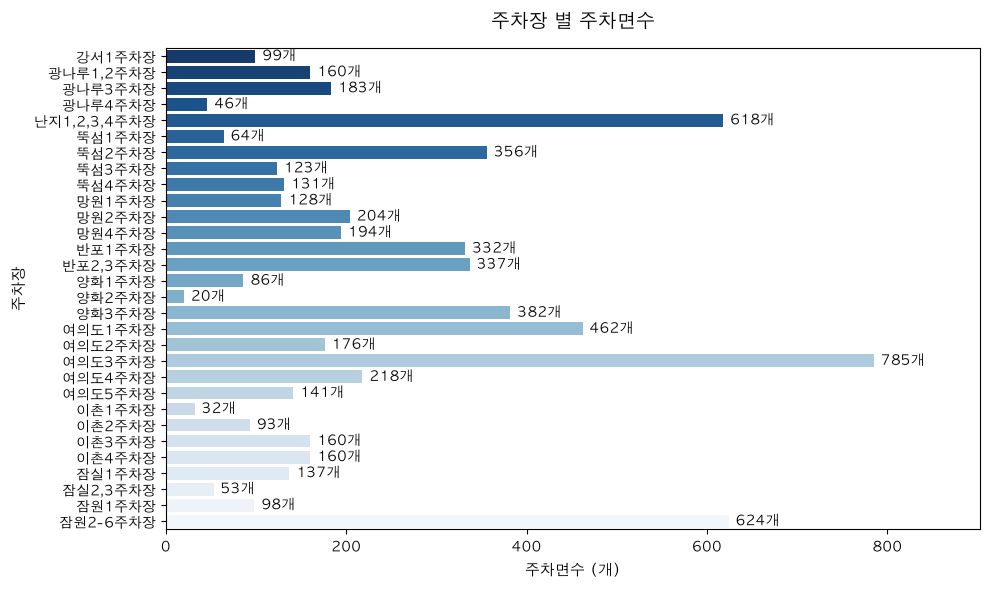

In [26]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=master_df,
    x='PRK_CNT',
    y='PKLT_TYPE',
    hue='PKLT_TYPE',
    palette='Blues_r',
    legend=False
)

# 막대 오른쪽에 수치 라벨 추가
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width)}개',
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            ha='left',
            va='center',
            fontsize=10
        )

plt.title('주차장 별 주차면수', fontsize=14, pad=15)
plt.xlabel('주차면수 (개)', fontsize=11)
plt.ylabel('주차장', fontsize=11)

# 레이블이 잘리지 않도록 x축 오른쪽 여백 살짝 확장
ax.set_xlim(0, master_df['PRK_CNT'].max() * 1.15)

plt.tight_layout()
plt.show()

* '여의도 3주차장'의 주차면수는 785개로 가장 많은 면수를 확보하고 있고, <br>
뒤를 이어 '난지 1,2,3,4 주차장'이 618개로 뒤를 잇고 있습니다.
* 다만, 이름에서 파악되듯 '난지 1,2,3,4' 주차장은 4개의 주차공간이 합쳐져서 집계되었을 가능성이 있습니다.

## 지구별 주차장 위치 확인

In [27]:
# 1. 컬럼명 지정
lat_col = 'PSTN_INFO_LAT'
lon_col = 'PSTN_INFO_LOT'
district_col = 'DSTRCT_TYPE'  # 실제 지구명 컬럼명에 맞게 확인 (예: 'PRK_PLC', 'DISTRICT_NM' 등)

# 2. 주차장 단위 중복 제거 및 결측치 제거
parking_map_df = master_df[['PKLT_TYPE', 'PKLT_OPER_BZENTY', district_col, lat_col, lon_col]].drop_duplicates(subset=['PKLT_TYPE']).dropna(subset=[lat_col, lon_col])

# 3. 한강 중심 좌표로 기본 지도 생성
m = folium.Map(
    location=[37.5300, 126.9800],
    zoom_start=11,
    tiles='cartodbpositron',
    scrollWheelZoom=False
)

# 4. 지구별 고유 색상 팔레트 정의 (11개 지구 지원 팔레트)
districts = parking_map_df[district_col].dropna().unique()
palette = [
    '#E63946', '#1D3557', '#457B9D', '#2A9D8F', '#E76F51', 
    '#9B5DE5', '#F4A261', '#3A86FF', '#06D6A0', '#FFB703', 
    '#6D597A', '#118AB2'
]
color_map = {dist: palette[i % len(palette)] for i, dist in enumerate(districts)}

# 5. 지구별 레이어(FeatureGroup) 생성 및 마커 추가
for dist in districts:
    fg = folium.FeatureGroup(name=f"📍 {dist}")
    dist_df = parking_map_df[parking_map_df[district_col] == dist]
    
    for _, row in dist_df.iterrows():
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=7,
            popup=folium.Popup(
                f"<b>{row['PKLT_TYPE']}</b><br>"
                f"<span style='color:gray;'>지구:</span> {row[district_col]}<br>"
                f"<span style='color:gray;'>운영사:</span> {row['PKLT_OPER_BZENTY']}",
                max_width=220
            ),
            tooltip=f"{row['PKLT_TYPE']} ({row[district_col]})",
            color='#ffffff',
            weight=1.5,
            fill=True,
            fill_color=color_map[dist],
            fill_opacity=0.85
        ).add_to(fg)
    
    fg.add_to(m)

# 6. 우측 상단 고정 범례(Legend) HTML 추가
legend_items = "".join([
    f"<li style='margin-bottom: 3px;'><span style='background:{color_map[d]}; width:11px; height:11px; display:inline-block; border-radius:50%; margin-right:6px;'></span>{d}</li>"
    for d in districts
])

legend_html = f'''
<div style="
    position: fixed; 
    top: 25px; right: 25px; width: 180px; 
    max-height: 400px;
    overflow-y: auto;
    background-color: rgba(255, 255, 255, 0.95);
    border: 1px solid #ccc;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
    border-radius: 8px;
    z-index: 9999; 
    font-size: 11px;
    font-family: sans-serif;
    padding: 10px 14px;
">
    <div style="font-weight: bold; margin-bottom: 8px; font-size: 12px;">📌 한강공원 지구</div>
    <ul style="list-style: none; padding-left: 0; margin: 0; line-height: 1.4;">
        {legend_items}
    </ul>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# 7. 출력
m

* 지구는 각 주차장의 상위 개념 파악되며, <br>
각 지구에 맞춰서 주차장이 밀집되어 있는 형태를 보입니다.

## 각 지구별 주차장 규모 파악
* 주차장에 따라 1개소 혹은 2개소 이상의 면수가 표현되고 있고, <br>
각 주차장은 소속된 지구에 밀집되어 있는 형태를 보이므로, 각 지구별 주차장 규모를 확인합니다.

In [28]:
dstrct_summary = master_df.groupby('DSTRCT_TYPE').agg(
    dstrct_park_count=('PRK_CNT', 'sum')
).reset_index().sort_values(by='dstrct_park_count', ascending=False)

display(dstrct_summary)

,DSTRCT_TYPE,dstrct_park_count
7,여의도,1782
10,잠원,722
3,뚝섬,674
5,반포,669
2,난지,618
4,망원,526
6,양화,488
8,이촌,445
1,광나루,389
9,잠실,190


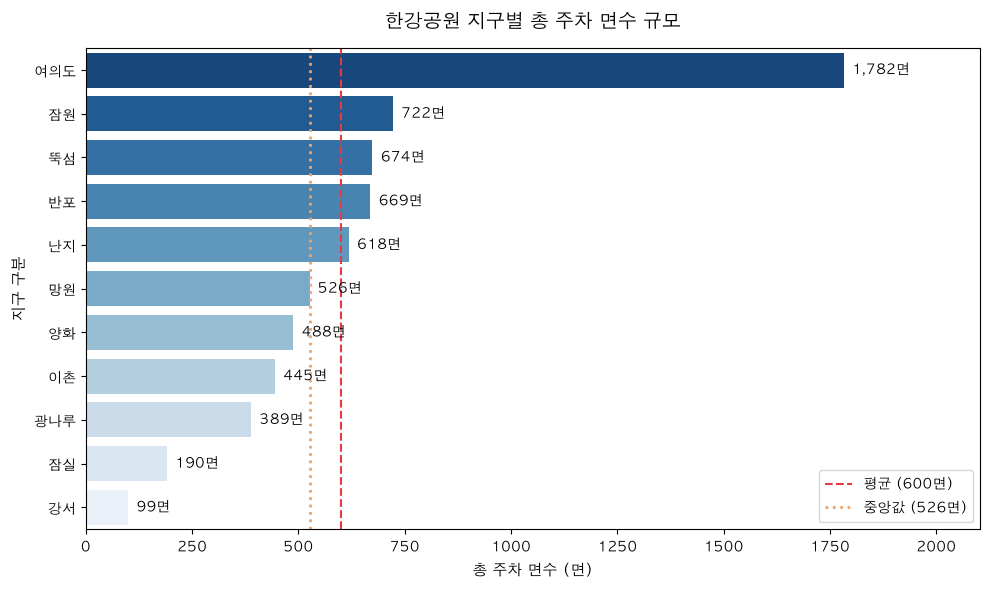

In [29]:
plt.figure(figsize=(10, 6))

# 1. 평균 및 중앙값 계산
mean_count = dstrct_summary['dstrct_park_count'].mean()
median_count = dstrct_summary['dstrct_park_count'].median()

# 2. 가로 막대 그래프 생성
ax = sns.barplot(
    data=dstrct_summary,
    x='dstrct_park_count',
    y='DSTRCT_TYPE',
    hue='DSTRCT_TYPE',
    palette='Blues_r',
    legend=False
)

# 3. 평균선 및 중앙값선 추가
ax.axvline(
    x=mean_count,
    color='#E63946',
    linestyle='--',
    linewidth=1.5,
    label=f'평균 ({mean_count:,.0f}면)'
)
ax.axvline(
    x=median_count,
    color='#F4A261',
    linestyle=':',
    linewidth=2.0,
    label=f'중앙값 ({median_count:,.0f}면)'
)

# 4. 막대 우측 수치 라벨 추가
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(
            f'{int(width):,}면',
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(6, 0),
            textcoords="offset points",
            ha='left',
            va='center',
            fontsize=10
        )

plt.title('한강공원 지구별 총 주차 면수 규모', fontsize=14, pad=15)
plt.xlabel('총 주차 면수 (면)', fontsize=11)
plt.ylabel('지구 구분', fontsize=11)

# 범례 표시 및 오른쪽 여백 확장
plt.legend(loc='lower right', frameon=True)
ax.set_xlim(0, dstrct_summary['dstrct_park_count'].max() * 1.18)

plt.tight_layout()
plt.show()

* 여의도는 다른 지구에 비해 압도적인 많은 주차면수를 확보하고 있습니다.
* 양화, 이촌, 광나루, 잠실, 강서 지구는 다른 지구에 비해 부족한 주차면수를 확보하고 있습니다.

## 주차장 별 요금 파악
* 요금 관련 데이터들이 차이를 보이고 있었던 것을 확인할 수 있었습니다.
* 나라에서 운영하고 있는 주차장이 실제 요금의 차이가 있는지 확인하고,<br>
전일 요금에 0원의 값이 있는 부분은 이상치로 판단할 수 있기에 확인을 요금을 중심으로 확인을 진행합니다.

In [30]:
# 요금관련 컬럼 정의 (차이가 발생한)
diff_fee_cols = [ 'EXMPTN_HR', 'BSC_CRG', 'INTR_CRG', 'PRVDY_CRG', 'PRD_AMT' ]

# 주차장명(또는 식별 컬럼)과 함께 확인
cols_to_show = ['PKLT_TYPE'] + diff_fee_cols

master_df[cols_to_show].drop_duplicates().reset_index(drop=True)

,PKLT_TYPE,EXMPTN_HR,BSC_CRG,INTR_CRG,PRVDY_CRG,PRD_AMT
0,강서1주차장,10,1000,200,10000,50000
1,"광나루1,2주차장",10,1000,200,10000,50000
2,광나루3주차장,10,1000,200,10000,50000
3,광나루4주차장,10,1000,200,10000,50000
4,"난지1,2,3,4주차장",10,1000,200,10000,50000
5,뚝섬1주차장,10,1000,200,10000,50000
6,뚝섬2주차장,10,1000,200,10000,50000
7,뚝섬3주차장,10,1000,200,10000,50000
8,뚝섬4주차장,10,1000,200,10000,50000
9,망원1주차장,10,1000,200,10000,50000


* 일부 데이터가 0원으로 발생하는 현상 발견
* 한강 공원 주차정보 홈페이지에 들어가서 직접 확인 진행결과
* 해당 주차장의 특성이라기보다는 데이터 자체의 누락 가능성이 크다고 판단됩니다.
* 잠원 주차정보<br>
https://hangang.seoul.go.kr/www/contents/748.do?mid=456
* 여의도 주차정보<br>
https://hangang.seoul.go.kr/www/contents/752.do?mid=475
---
* 잠원2-6주차장 면제시간 10분
* 여의도 2주차장 전일 요금 15,000원
* 값 대체 진행

In [31]:
# 값 대체 작업 진행
# 1. 잠원 2-6 주차장 면제시간(EXMPTN_HR) -> 10분으로 대체
master_df.loc[master_df['PKLT_TYPE'] == '잠원2-6주차장', 'EXMPTN_HR'] = 10

# 2. 여의도 2주차장 전일 요금(PRVDY_CRG) -> 15,000원으로 대체
master_df.loc[master_df['PKLT_TYPE'] == '여의도2주차장', 'PRVDY_CRG'] = 15000

In [32]:
# 변경 확인 진행
master_df[cols_to_show].drop_duplicates().reset_index(drop=True)

,PKLT_TYPE,EXMPTN_HR,BSC_CRG,INTR_CRG,PRVDY_CRG,PRD_AMT
0,강서1주차장,10,1000,200,10000,50000
1,"광나루1,2주차장",10,1000,200,10000,50000
2,광나루3주차장,10,1000,200,10000,50000
3,광나루4주차장,10,1000,200,10000,50000
4,"난지1,2,3,4주차장",10,1000,200,10000,50000
5,뚝섬1주차장,10,1000,200,10000,50000
6,뚝섬2주차장,10,1000,200,10000,50000
7,뚝섬3주차장,10,1000,200,10000,50000
8,뚝섬4주차장,10,1000,200,10000,50000
9,망원1주차장,10,1000,200,10000,50000


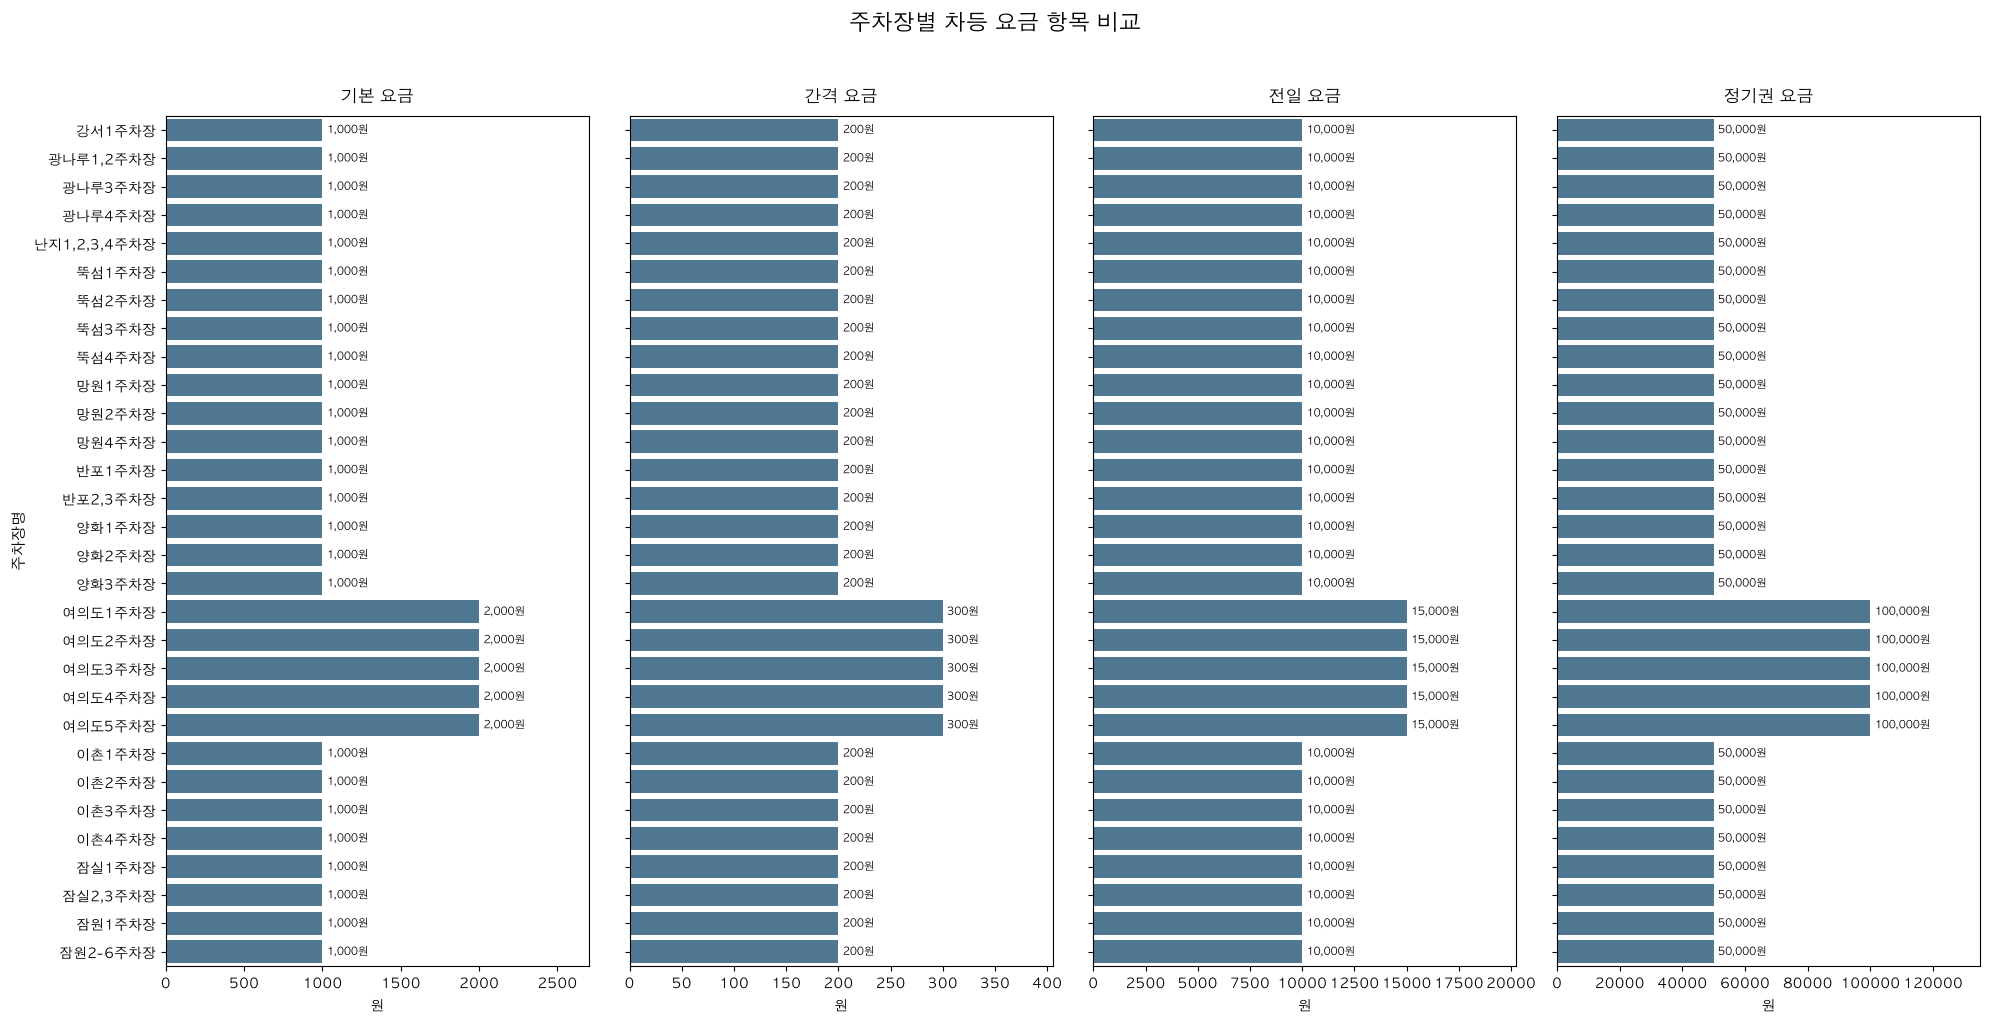

In [33]:
# 면제 시간은 값 대체 후 모두 동일 확인
diff_fee_cols = ['BSC_CRG', 'INTR_CRG', 'PRVDY_CRG', 'PRD_AMT' ]

fig, axes = plt.subplots(1, len(diff_fee_cols), figsize=(20, 10), sharey=True)

# 컬럼별 한글 타이틀 및 단위 매핑
col_info = {
    'BSC_CRG': ('기본 요금', '원'),
    'INTR_CRG': ('간격 요금', '원'),
    'PRVDY_CRG': ('전일 요금', '원'),
    'PRD_AMT': ('정기권 요금', '원')
}

# 주차장명 기준 정렬 (가독성 목적)
sorted_df = master_df.sort_values(by='PKLT_TYPE')

for ax, col in zip(axes, diff_fee_cols):
    title, unit = col_info.get(col, (col, ''))
    
    sns.barplot(
        data=sorted_df,
        x=col,
        y='PKLT_TYPE',
        ax=ax,
        color='#457B9D'
    )
    
    # 막대 끝에 수치 라벨 표기
    for p in ax.patches:
        width = p.get_width()
        ax.annotate(
            f'{int(width):,}{unit}',
            xy=(width, p.get_y() + p.get_height() / 2),
            xytext=(3, 0),
            textcoords="offset points",
            ha='left',
            va='center',
            fontsize=8
        )
    
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_xlabel(unit, fontsize=10)
    ax.set_ylabel('' if ax != axes[0] else '주차장명', fontsize=11)
    ax.set_xlim(0, sorted_df[col].max() * 1.35)

plt.suptitle('주차장별 차등 요금 항목 비교', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

* 여의도를 제외한 모든 주차장은 동일한 요금을 받고 있으며, <br>
여의도에 주차장은 다른 주차장에 비해 모든 요금이 1.5 ~ 2배정도 높음을 확인할 수 있었습니다.

## 업체별 담당 주차장 수 파악

In [34]:
oper_summary = master_df.groupby('PKLT_OPER_BZENTY').agg(
    parking_lot_count=('PKLT_TYPE', 'nunique')
).reset_index().sort_values(by='parking_lot_count', ascending=False)

display(oper_summary)

,PKLT_OPER_BZENTY,parking_lot_count
1,(주)케이엠파크,15
0,(주)씨앤에스자산관리_양화_강서,4
3,공우이엔씨(주)_뚝섬,4
5,리스크테크(주),4
2,(주)하이파킹,2
4,공우이엔씨(주)_여의도_3,1


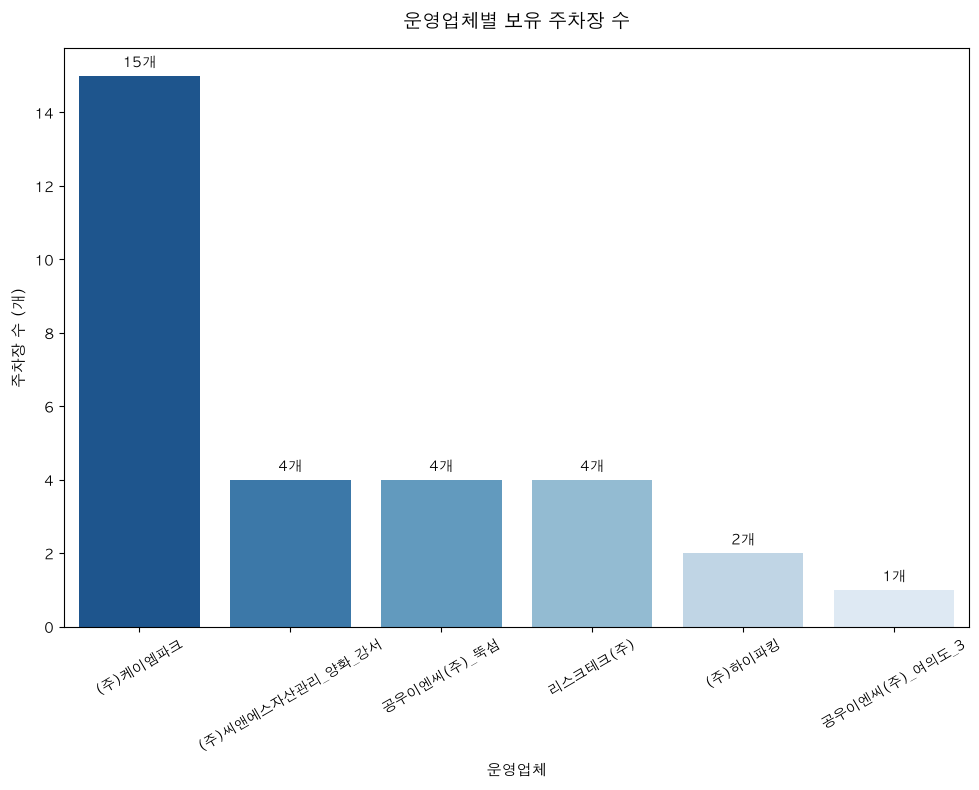

In [35]:
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=oper_summary,
    x='PKLT_OPER_BZENTY',
    y='parking_lot_count',
    hue='PKLT_OPER_BZENTY',  # 최신 seaborn 문법 적용
    palette='Blues_r',
    legend=False             # 범례 숨김
)

# 막대 위에 수치 라벨 추가
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{int(height)}개',
            xy=(p.get_x() + p.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center',
            va='bottom',
            fontsize=10
        )

plt.title('운영업체별 보유 주차장 수', fontsize=14, pad=15)
plt.xlabel('운영업체', fontsize=11)
plt.ylabel('주차장 수 (개)', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

* 현재 한강 공원 주차장 관리는 총 6개의 업체에 의해서 이루어지고 있다.
* 그 중 가장 많은 구역을 담당하고 있는 업체는 '(주) 케이엠파크'로 한강 공원 주차장의 50%를 관리하고 있다.

## 업체별 담당 주차장 위치 확인

In [36]:
# 1. 위경도 컬럼명 지정
lat_col = 'PSTN_INFO_LAT'
lon_col = 'PSTN_INFO_LOT'

# 2. 주차장 단위 중복 제거 및 결측치 제거
parking_map_df = master_df[['PKLT_TYPE', 'PKLT_OPER_BZENTY', lat_col, lon_col]].drop_duplicates(subset=['PKLT_TYPE']).dropna(subset=[lat_col, lon_col])

# 3. 한강 중심 좌표로 기본 지도 생성 (깔끔한 CartoDB Positron 배경)
m = folium.Map(
    location=[37.5700, 126.9800],
    zoom_start=11,
    tiles='cartodbpositron',
    scrollWheelZoom=False
)

# 4. 운영 업체별 고유 색상 팔레트 정의
operators = parking_map_df['PKLT_OPER_BZENTY'].dropna().unique()
palette = ['#E63946', '#1D3557', '#457B9D', '#2A9D8F', '#E76F51', '#9B5DE5', '#F4A261', '#3A86FF']
color_map = {oper: palette[i % len(palette)] for i, oper in enumerate(operators)}

# 5. 업체별 레이어(FeatureGroup) 생성 및 점(CircleMarker) 추가
for oper in operators:
    fg = folium.FeatureGroup(name=f"🏢 {oper}")
    oper_df = parking_map_df[parking_map_df['PKLT_OPER_BZENTY'] == oper]
    
    for _, row in oper_df.iterrows():
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=7,
            popup=folium.Popup(f"<b>{row['PKLT_TYPE']}</b><br><span style='color:gray;'>운영사:</span> {row['PKLT_OPER_BZENTY']}", max_width=220),
            tooltip=f"{row['PKLT_TYPE']} ({row['PKLT_OPER_BZENTY']})",
            color='#ffffff',               # 테두리 흰색 (가독성 향상)
            weight=1.5,
            fill=True,
            fill_color=color_map[oper],     # 업체별 색상 적용
            fill_opacity=0.85
        ).add_to(fg)
    
    fg.add_to(m)

# 6. 지도 우측 상단에 레이어 켜기/끄기 컨트롤 추가
# folium.LayerControl(collapsed=False).add_to(m)

# 7. 좌측 하단 고정 범례(Legend) HTML 추가
legend_items = "".join([
    f"<li><span style='background:{color_map[op]}; width:12px; height:12px; display:inline-block; border-radius:50%; margin-right:6px;'></span>{op}</li>"
    for op in operators
])

legend_html = f'''
<div style="
    position: fixed; 
    top: 25px; right: 25px; width: 300px; 
    background-color: rgba(255, 255, 255, 0.9);
    border: 1px solid #ccc;
    box-shadow: 2px 2px 6px rgba(0,0,0,0.2);
    border-radius: 8px;
    z-index: 9999; 
    font-size: 10px;
    font-family: sans-serif;
    padding: 10px 14px;
">
    <div style="font-weight: bold; margin-bottom: 6px; font-size: 13px;">📌 운영 업체 범례</div>
    <ul style="list-style: none; padding-left: 0; margin: 0; line-height: 1.6;">
        {legend_items}
    </ul>
</div>
'''
m.get_root().html.add_child(folium.Element(legend_html))

# 8. 주피터 노트북에서 바로 출력
m

* 지역 기반 위탁 운영: <br>
개별 주차장 단위가 아닌, 특정 권역/지역 단위로 구역을 묶어 관리하는 경향이 보입니다.

* 관리 구역 집중도: <br>
각 업체별 담당 주차장은 지리적으로 인접하게 밀집되어 있으며, 가장 많은 주차장을 위탁 운영하는 (주)케이엠파크 역시 '서울 중심'과 '동부권'에 집중되어 있습니다.

# 🅿️ 한강공원 주차장 x 일별 이용 현황 EDA 

* 이미 집계하여 구축해둔 데이터 마트를 통해 분석을 진행합니다.
* 다만, 해당 데이터는 일별 이용 현황이 집계된 28개소의 주차장에 대한 데이터로 일별 이용 현황이 집계되지 못한 `망원4주차장`, `이촌4주차장`에 대한 정보는 누락되어 있습니다.

## 데이터 호출

In [37]:
df = pd.read_csv('../data/final_dataset/bq-results-20260825-092945-1787650226335.csv')

df.head(2)

,DSTRCT_CODE,PKLT_NM,PRK_CNTOM,UTZTN_HR,DT,DSTRCT_TYPE,PKLT_TYPE,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,PWDBS_PRK_CNT,PRD_PRK_CNT,WD_OPER_BGNG_TM,WD_OPER_END_TM,WE_OPER_BGNG_TM,WE_OPER_END_TM,EXMPTN_HR,BSC_HR,BSC_CRG,INTR_HR,INTR_CRG,PRVDY_CRG,WKLY_CRG,NGHT_CRG,PRD_AMT,PKLT_OPER_BZENTY,is_holiday,temp,precip
0,PLT-001,강서1주차장,234,14721,2026-04-28,강서,강서1주차장,37.585709,126.818279,99,0,0,06:00,23:00,06:00,23:00,10,30,1000,10,200,10000,0,0,50000,(주)씨앤에스자산관리_양화_강서,False,13.3,0.2
1,PLT-001,강서1주차장,179,6974,2026-02-13,강서,강서1주차장,37.585709,126.818279,99,0,0,06:00,23:00,06:00,23:00,10,30,1000,10,200,10000,0,0,50000,(주)씨앤에스자산관리_양화_강서,False,5.3,0.0


* 데이터 프레임 컬럼 설명 (호출 데이터 기준)

| 컬럼명 | 컬럼 설명 | 비고 | 
| - | - | - |
| DSTRCT_CODE | 지구 코드 | |
| PKLT_NM | 주차장 이름| |
| PRK_CNTOM | 주차대수 | |
| UTZTN_HR | 지구 이름| |
| PKLT_TYPE | 주차장 이름 | |
| PSTN_INFO_LAT | 위도 | |
| PSTN_INFO_LOT | 경도 | |
| PRK_CNT | 면수 | |
| PWDBS_PRK_CNT | 장애면수 | |
| PRD_PRK_CNT | 정기면수 | |
| WD_OPER_BGNG_TM | 주중 이용시간 시작 | |
| WD_OPER_END_TM | 주중 이용시간 종료 | |
| WE_OPER_BGNG_TM | 주말 이용시간 시작 | |
| WE_OPER_END_TM | 주말 이용시간 종료 | |
| EXMPTN_HR | 면제 시간 | |
| BSC_HR | 기본 시간 | |
| BSC_CRG | 기본 요금 | |
| INTR_HR | 간격 시간 | |
| INTR_CRG | 간격 요금 | |
| PRVDY_CRG | 전일 요금 | |
| WKLY_CRG | 주간 요금 | |
| NGHT_CRG | 야간 요금 | |
| PRD_AMT | 정기권 금액 | |
| PKLT_OPER_BZENTY | 주차장 운영업체 | |
| is_holiday | 공휴일 여부 | |
| temp | 평균 온도 (°C) | |
| precip | 일 강수량 (mm) | |

## 전처리

### 1차 전처리 (중복 개념 컬럼 정리 / 데이터 재정렬 진행)
* 중복되는 개념에 대한 컬럼 정리 진행 필요
* 일별 이용 현황에서 활용되는 `DT` 컬럼을 기준으로 재정렬 진행
---
* `DSTRCT_CODE` 컬럼 삭제
* `PKLT_TYPE` 컬럼 삭제
* `DT` 컬럼 맨 앞으로 위치해서 재정렬

In [38]:
# 지구 구분 코드
df['DSTRCT_CODE'].nunique() # 11
# 지구 구분 이름
df['DSTRCT_TYPE'].nunique() # 11

# 특정 컬럼 삭제 (존재하지 않아도 에러 안 나게 errors='ignore' 설정)
df = df.drop(columns=['DSTRCT_CODE', 'PKLT_TYPE'], errors='ignore')

# 'DT' 컬럼을 맨 앞으로 이동하여 컬럼 재정렬
if 'DT' in df.columns:
    other_cols = [col for col in df.columns if col != 'DT']
    df = df[['DT'] + other_cols]

# 'DT' 컬럼을 datetime으로 변환 후 오름차순 정렬 (내림차순은 ascending=False)
df['DT'] = pd.to_datetime(df['DT'])
df = df.sort_values(by='DT').reset_index(drop=True)

# 확인
df.head(2)

,DT,PKLT_NM,PRK_CNTOM,UTZTN_HR,DSTRCT_TYPE,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,PWDBS_PRK_CNT,PRD_PRK_CNT,WD_OPER_BGNG_TM,WD_OPER_END_TM,WE_OPER_BGNG_TM,WE_OPER_END_TM,EXMPTN_HR,BSC_HR,BSC_CRG,INTR_HR,INTR_CRG,PRVDY_CRG,WKLY_CRG,NGHT_CRG,PRD_AMT,PKLT_OPER_BZENTY,is_holiday,temp,precip
0,2025-08-23,여의도3주차장,1810,237539,여의도,37.532383,126.923676,785,0,0,06:00,23:00,06:00,23:00,10,30,2000,10,300,15000,0,0,100000,공우이엔씨(주)_여의도_3,False,29.3,0.0
1,2025-08-23,강서1주차장,347,24337,강서,37.585709,126.818279,99,0,0,06:00,23:00,06:00,23:00,10,30,1000,10,200,10000,0,0,50000,(주)씨앤에스자산관리_양화_강서,False,29.3,0.0


In [39]:
# 결측값 확인
df.isna().sum().sum() # 0

# 중복값 확인
df.duplicated().sum() # 0

# 통계량 확인
df.describe()

,DT,PRK_CNTOM,UTZTN_HR,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,PWDBS_PRK_CNT,PRD_PRK_CNT,EXMPTN_HR,BSC_HR,BSC_CRG,INTR_HR,INTR_CRG,PRVDY_CRG,WKLY_CRG,NGHT_CRG,PRD_AMT,temp,precip
count,10220,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.0,10220.0,10220.000000,10220.0,10220.000000,10220.0,10220.000000,10220.000000,10220.0,10220.0,10220.000000,10220.000000,10220.000000
mean,2026-02-21 00:55:13.972602,852.895695,97304.169765,37.532567,126.987117,223.142857,0.0,0.0,9.642857,30.0,1178.571429,10.0,217.857143,10357.142857,0.0,0.0,58928.571429,14.363014,3.867397
min,2025-08-23 00:00:00,14.000000,459.000000,37.510071,126.818279,20.000000,0.0,0.0,0.000000,30.0,1000.000000,10.0,200.000000,0.000000,0.0,0.0,50000.000000,-9.700000,0.000000
25%,2025-11-22 00:00:00,281.000000,28746.750000,37.519468,126.912665,96.750000,0.0,0.0,10.000000,30.0,1000.000000,10.0,200.000000,10000.000000,0.0,0.0,50000.000000,5.700000,0.000000
50%,2026-02-21 00:00:00,551.000000,58526.000000,37.529075,126.987425,150.500000,0.0,0.0,10.000000,30.0,1000.000000,10.0,200.000000,10000.000000,0.0,0.0,50000.000000,15.200000,0.000000
75%,2026-05-23 00:00:00,1198.000000,112002.750000,37.540679,127.068895,333.250000,0.0,0.0,10.000000,30.0,1000.000000,10.0,200.000000,10000.000000,0.0,0.0,50000.000000,24.000000,0.600000
max,2026-08-24 00:00:00,6034.000000,742747.000000,37.585709,127.123160,785.000000,0.0,0.0,10.000000,30.0,2000.000000,10.0,300.000000,15000.000000,0.0,0.0,100000.000000,33.100000,119.700000
std,NaN,831.488042,109986.468252,0.016836,0.084111,192.849990,0.0,0.0,1.855860,0.0,383.011785,0.0,38.301179,2648.771908,0.0,0.0,19150.589252,10.858757,12.228792


### 2차 컬럼 정리 (분산 0 컬럼 삭제 진행)

* 주차장 마스터 테이블 분석을 통해서도 확인했지만, 전체적으로 같은 값을 가진 컬럼들을 발견할 수 있습니다.
* (분산(std)이 0인 값들로 판단이 가능)
* 분산이 0인 컬럼
  * `PWDBS_PRK_CNT`, `PRD_PRK_CNT`, `BSC_HR`, `INTR_HR`, `WKLY_CRG`, `NGHT_CRG`
  * `장애면수`, `정기면수`, `기본 시간`, `간격 시간`, `주간 요금`, `야간 요금`
* 모든 값이 일치하므로 모델링 진행 시 변별력이 없고,
* 분석과 관련해서도 유의미한 차이를 만들어내지 못할 가능성이 있습니다.
* 또한 필요 시 값을 강제로 부여하며 진행이 가능한 것으로 판단하여 컬럼 삭제 진행.

In [44]:
# 분산이 0인 단일값 컬럼 리스트 정의 (중복 제거)
drop_cols = ['PWDBS_PRK_CNT', 'PRD_PRK_CNT', 'BSC_HR', 'INTR_HR', 'WKLY_CRG', 'NGHT_CRG']

# 컬럼 일괄 삭제 (errors='ignore'로 존재하지 않는 컬럼이 있어도 에러 방지)
df = df.drop(columns=drop_cols, errors='ignore')

### 3차 전처리 (파생 변수 생성 및 데이터 변환 진행)
* 주말 여부 컬럼 추가 (TRUE = 1 , FALSE = 0)
* 공휴일 여부 데이터 라벨링 진행 (TRUE = 1 , FALSE = 0)

In [45]:
# DT 컬럼 기준 주말 여부 생성 (토요일=5, 일요일=6 -> 1, 평일 -> 0)
df['is_weekend'] = df['DT'].dt.dayofweek.isin([5, 6]).astype(int)

# 기존 is_holiday 컬럼 라벨링 변환 (TRUE -> 1, FALSE -> 0)
df['is_holiday'] = df['is_holiday'].astype(int)

# 결과 확인
print(df[['DT', 'is_weekend', 'is_holiday']].head())
print(df[['is_weekend', 'is_holiday']].value_counts())

          DT  is_weekend  is_holiday
0 2025-08-23           1           0
1 2025-08-23           1           0
2 2025-08-23           1           0
3 2025-08-23           1           0
4 2025-08-23           1           0
is_weekend  is_holiday
0           0             6916
1           0             2828
0           1              364
1           1              112
Name: count, dtype: int64


### 4차 전처리 진행 (master_df 전처리 수행 및 분산 0값 추가 삭제)
* 이미 구축이 완료된 데이터 마트는 상단의 park_master 기반으로 집계되었기 때문에,
* 상단에 처리된 전처리를 동일하게 수행해야 합니다.
* 0으로 발견된 값 중 `EXMPTN_HR`와 `PRVDY_CRG`에 대한 대체 진행합니다.
* `EXMPTN_HR` 또한 모두가 같은 값이므로 컬럼 삭제를 진행합니다.

In [54]:
# 값 대체 작업 진행
# 1. 잠원 2-6 주차장 면제시간(EXMPTN_HR) -> 10분으로 대체
df.loc[df['PKLT_NM'] == '잠원2-6주차장', 'EXMPTN_HR'] = 10

# 2. 여의도 2주차장 전일 요금(PRVDY_CRG) -> 15,000원으로 대체
df.loc[df['PKLT_NM'] == '여의도2주차장', 'PRVDY_CRG'] = 15000

df.describe()

,DT,PRK_CNTOM,UTZTN_HR,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,EXMPTN_HR,BSC_CRG,INTR_CRG,PRVDY_CRG,PRD_AMT,is_holiday,temp,precip,is_weekend
count,10220,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.0,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000,10220.000000
mean,2026-02-21 00:55:13.972602,852.895695,97304.169765,37.532567,126.987117,223.142857,10.0,1178.571429,217.857143,10892.857143,58928.571429,0.046575,14.363014,3.867397,0.287671
min,2025-08-23 00:00:00,14.000000,459.000000,37.510071,126.818279,20.000000,10.0,1000.000000,200.000000,10000.000000,50000.000000,0.000000,-9.700000,0.000000,0.000000
25%,2025-11-22 00:00:00,281.000000,28746.750000,37.519468,126.912665,96.750000,10.0,1000.000000,200.000000,10000.000000,50000.000000,0.000000,5.700000,0.000000,0.000000
50%,2026-02-21 00:00:00,551.000000,58526.000000,37.529075,126.987425,150.500000,10.0,1000.000000,200.000000,10000.000000,50000.000000,0.000000,15.200000,0.000000,0.000000
75%,2026-05-23 00:00:00,1198.000000,112002.750000,37.540679,127.068895,333.250000,10.0,1000.000000,200.000000,10000.000000,50000.000000,0.000000,24.000000,0.600000,1.000000
max,2026-08-24 00:00:00,6034.000000,742747.000000,37.585709,127.123160,785.000000,10.0,2000.000000,300.000000,15000.000000,100000.000000,1.000000,33.100000,119.700000,1.000000
std,NaN,831.488042,109986.468252,0.016836,0.084111,192.849990,0.0,383.011785,38.301179,1915.058925,19150.589252,0.210738,10.858757,12.228792,0.452699


In [55]:
# 컬럼 일괄 삭제 (errors='ignore'로 존재하지 않는 컬럼이 있어도 에러 방지)
df = df.drop(columns='EXMPTN_HR', errors='ignore')

### 5차 전처리 (전체적으로 동일한 특징으로 파악되는 컬럼 추가 삭제 진행)
* 숫자형 데이터의 경우 분산 값으로 확인하여 동일한 값을 가지고 있는 컬럼을 삭제를 진행하였습니다.
* 하지만 이용 시간 컬럼들은 모든 주차장에서 동일한 특징을 가지고 있지만, 숫자형이 아니어서 컬럼 삭제에서 누락이 되었기에 추가적으로 삭제를 진행합니다.

In [62]:
# 컬럼 일괄 삭제 (errors='ignore'로 존재하지 않는 컬럼이 있어도 에러 방지)
drop_cols = ['WD_OPER_BGNG_TM', 'WD_OPER_END_TM', 'WE_OPER_BGNG_TM', 'WE_OPER_END_TM']

df = df.drop(columns=drop_cols, errors='ignore')

## EDA

In [66]:
df.head(2)

,DT,PKLT_NM,PRK_CNTOM,UTZTN_HR,DSTRCT_TYPE,PSTN_INFO_LAT,PSTN_INFO_LOT,PRK_CNT,BSC_CRG,INTR_CRG,PRVDY_CRG,PRD_AMT,PKLT_OPER_BZENTY,is_holiday,temp,precip,is_weekend
0,2025-08-23,여의도3주차장,1810,237539,여의도,37.532383,126.923676,785,2000,300,15000,100000,공우이엔씨(주)_여의도_3,0,29.3,0.0,1
1,2025-08-23,강서1주차장,347,24337,강서,37.585709,126.818279,99,1000,200,10000,50000,(주)씨앤에스자산관리_양화_강서,0,29.3,0.0,1
